Ok time for some exploration of the data. We're gonna need pandas for this. 

In [126]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
READ_DIR = Path("../") / "data" / "processed"

Ok lets import the csvs

In [128]:
flows_df = pd.read_csv(READ_DIR / 'flows.csv')
generation_df = pd.read_csv(READ_DIR / 'generation.csv')
prices_df = pd.read_csv(READ_DIR / 'prices.csv')

Data is there. Lets do a data quality pass.

In [129]:
flows_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   zone_from  1344 non-null   str    
 1   zone_to    1344 non-null   str    
 2   timestamp  1344 non-null   str    
 3   flow_mw    1344 non-null   float64
dtypes: float64(1), str(3)
memory usage: 42.1 KB


Ok, we convert all the timestamps into datetime format (.csv do not natively carry that), and force utc since we might be dealing with different time zones. We'll get rid of any misaligned stuff later by doing an inner merge.

In [130]:
# Convert the timestamp column to datetime
flows_df['timestamp'] = pd.to_datetime(flows_df['timestamp'], utc=True)
generation_df["timestamp"]=pd.to_datetime(generation_df["timestamp"], utc=True)
prices_df["timestamp"]=pd.to_datetime(prices_df["timestamp"], utc=True)

Lets check for duplicates.

In [131]:
flows_df[flows_df["timestamp"].duplicated(keep=False)].sort_values("timestamp")

,zone_from,zone_to,timestamp,flow_mw
0,DE_LU,SE_4,2025-12-31 23:00:00+00:00,0.000000
672,SE_4,DE_LU,2025-12-31 23:00:00+00:00,216.864700
673,SE_4,DE_LU,2025-12-31 23:15:00+00:00,216.864685
1,DE_LU,SE_4,2025-12-31 23:15:00+00:00,0.000000
2,DE_LU,SE_4,2025-12-31 23:30:00+00:00,0.000000
...,...,...,...,...
669,DE_LU,SE_4,2026-01-07 22:15:00+00:00,0.000000
1342,SE_4,DE_LU,2026-01-07 22:30:00+00:00,216.693939
670,DE_LU,SE_4,2026-01-07 22:30:00+00:00,0.000000
671,DE_LU,SE_4,2026-01-07 22:45:00+00:00,0.000000


Yeah, thats to be expected, it uses the timestamp always twice each for each direction. Check.

In [132]:
generation_df[generation_df["timestamp"].duplicated(keep=False)].sort_values("timestamp")

,zone,timestamp,production_type,value_mw
0,DE_LU,2025-12-31 23:00:00+00:00,Biomass,4210.669292
13440,SE_4,2025-12-31 23:00:00+00:00,Wind Onshore,825.139000
672,DE_LU,2025-12-31 23:00:00+00:00,Fossil Brown coal/Lignite,4364.732450
12096,SE_4,2025-12-31 23:00:00+00:00,Other,147.193000
2016,DE_LU,2025-12-31 23:00:00+00:00,Fossil Gas,6662.260660
...,...,...,...,...
1343,DE_LU,2026-01-07 22:45:00+00:00,Fossil Brown coal/Lignite,9112.325100
12767,SE_4,2026-01-07 22:45:00+00:00,Other,217.146000
671,DE_LU,2026-01-07 22:45:00+00:00,Biomass,4079.226876
9407,DE_LU,2026-01-07 22:45:00+00:00,Waste,722.844000


Again, once for each combination of region and production type.

In [133]:
prices_df[prices_df["timestamp"].duplicated(keep=False)].sort_values("timestamp")

,zone,timestamp,price_eur_mwh
0,DE_LU,2025-12-31 23:00:00+00:00,63.64
673,SE_4,2025-12-31 23:00:00+00:00,41.58
674,SE_4,2025-12-31 23:15:00+00:00,40.87
1,DE_LU,2025-12-31 23:15:00+00:00,61.48
2,DE_LU,2025-12-31 23:30:00+00:00,58.00
...,...,...,...
670,DE_LU,2026-01-07 22:30:00+00:00,86.83
1344,SE_4,2026-01-07 22:45:00+00:00,59.30
671,DE_LU,2026-01-07 22:45:00+00:00,84.10
672,DE_LU,2026-01-07 23:00:00+00:00,86.88


OK, fine, that also makes sense, since we do each region. Right.

Lets instead check more granularily:

In [134]:
flows_df[["zone_from", "zone_to", "timestamp"]].duplicated().sum()

np.int64(0)

In [135]:
generation_df[["zone", "timestamp", "production_type"]].duplicated().sum()

np.int64(0)

In [136]:
prices_df[["zone", "timestamp"]].duplicated().sum()

np.int64(0)

Ok, good, no duplicates we care about.

Lets do some individual analysis.

In [137]:
generation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14112 entries, 0 to 14111
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   zone             14112 non-null  str                
 1   timestamp        14112 non-null  datetime64[us, UTC]
 2   production_type  14112 non-null  str                
 3   value_mw         14112 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(1), str(2)
memory usage: 441.1 KB


Lets see if generation is positive always.

In [138]:
generation_df.sort_values("value_mw", ascending=True).head(10)

,zone,timestamp,production_type,value_mw
4918,DE_LU,2026-01-03 04:30:00+00:00,Hydro Pumped Storage,-6033.1901
4917,DE_LU,2026-01-03 04:15:00+00:00,Hydro Pumped Storage,-5900.1391
4916,DE_LU,2026-01-03 04:00:00+00:00,Hydro Pumped Storage,-5796.4269
4919,DE_LU,2026-01-03 04:45:00+00:00,Hydro Pumped Storage,-5746.5970
4915,DE_LU,2026-01-03 03:45:00+00:00,Hydro Pumped Storage,-5725.7873
4753,DE_LU,2026-01-01 11:15:00+00:00,Hydro Pumped Storage,-5542.2458
4755,DE_LU,2026-01-01 11:45:00+00:00,Hydro Pumped Storage,-5439.9287
4750,DE_LU,2026-01-01 10:30:00+00:00,Hydro Pumped Storage,-5425.9150
4754,DE_LU,2026-01-01 11:30:00+00:00,Hydro Pumped Storage,-5404.6995
4752,DE_LU,2026-01-01 11:00:00+00:00,Hydro Pumped Storage,-5378.3117


In [139]:
generation_df.loc[generation_df["value_mw"] < 0].value_counts("production_type")

production_type
Hydro Pumped Storage    347
Name: count, dtype: int64

Ok its just the pumped hydro. Nice.

In [140]:
prices_df

,zone,timestamp,price_eur_mwh
0,DE_LU,2025-12-31 23:00:00+00:00,63.64
1,DE_LU,2025-12-31 23:15:00+00:00,61.48
2,DE_LU,2025-12-31 23:30:00+00:00,58.00
3,DE_LU,2025-12-31 23:45:00+00:00,49.99
4,DE_LU,2026-01-01 00:00:00+00:00,60.01
...,...,...,...
1341,SE_4,2026-01-07 22:00:00+00:00,67.26
1342,SE_4,2026-01-07 22:15:00+00:00,62.37
1343,SE_4,2026-01-07 22:30:00+00:00,60.56
1344,SE_4,2026-01-07 22:45:00+00:00,59.30


In [141]:
prices_df.loc[prices_df["price_eur_mwh"] < 0]

,zone,timestamp,price_eur_mwh
43,DE_LU,2026-01-01 09:45:00+00:00,-0.01
47,DE_LU,2026-01-01 10:45:00+00:00,-0.01
48,DE_LU,2026-01-01 11:00:00+00:00,-0.01
49,DE_LU,2026-01-01 11:15:00+00:00,-0.01
50,DE_LU,2026-01-01 11:30:00+00:00,-0.01
51,DE_LU,2026-01-01 11:45:00+00:00,-0.01
52,DE_LU,2026-01-01 12:00:00+00:00,-0.01
53,DE_LU,2026-01-01 12:15:00+00:00,-0.01
54,DE_LU,2026-01-01 12:30:00+00:00,-0.01
56,DE_LU,2026-01-01 13:00:00+00:00,-0.01


Yeah, that should be ok, a brief window of overcap.

In [142]:
flows_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   zone_from  1344 non-null   str                
 1   zone_to    1344 non-null   str                
 2   timestamp  1344 non-null   datetime64[us, UTC]
 3   flow_mw    1344 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), str(2)
memory usage: 42.1 KB


In [143]:
flows_df.sort_values("flow_mw", ascending=True).head(10)

,zone_from,zone_to,timestamp,flow_mw
1103,SE_4,DE_LU,2026-01-05 10:45:00+00:00,0.0
11,DE_LU,SE_4,2026-01-01 01:45:00+00:00,0.0
12,DE_LU,SE_4,2026-01-01 02:00:00+00:00,0.0
1074,SE_4,DE_LU,2026-01-05 03:30:00+00:00,0.0
1075,SE_4,DE_LU,2026-01-05 03:45:00+00:00,0.0
1076,SE_4,DE_LU,2026-01-05 04:00:00+00:00,0.0
1077,SE_4,DE_LU,2026-01-05 04:15:00+00:00,0.0
1078,SE_4,DE_LU,2026-01-05 04:30:00+00:00,0.0
1079,SE_4,DE_LU,2026-01-05 04:45:00+00:00,0.0
1080,SE_4,DE_LU,2026-01-05 05:00:00+00:00,0.0


Ok, no negative flows - they are always denoted by direction in pairs. Lets see later how i want the data, we could transform with directionality and negatives if we wanted.

In [144]:
print(generation_df.isna().sum())
print(prices_df.isna().sum())
print(flows_df.isna().sum())

zone               0
timestamp          0
production_type    0
value_mw           0
dtype: int64
zone             0
timestamp        0
price_eur_mwh    0
dtype: int64
zone_from    0
zone_to      0
timestamp    0
flow_mw      0
dtype: int64


No flows, ok so the data quality pass is done. Wait, length.

In [145]:
print(len(generation_df), len(prices_df), len(flows_df))

14112 1346 1344


In [146]:
prices_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   zone           1346 non-null   str                
 1   timestamp      1346 non-null   datetime64[us, UTC]
 2   price_eur_mwh  1346 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), str(1)
memory usage: 31.7 KB


In [147]:
print(prices_df["timestamp"].max())
print(prices_df["timestamp"].min())
print(flows_df["timestamp"].max())
print(flows_df["timestamp"].min())
print(generation_df["timestamp"].max())
print(generation_df["timestamp"].min())

2026-01-07 23:00:00+00:00
2025-12-31 23:00:00+00:00
2026-01-07 22:45:00+00:00
2025-12-31 23:00:00+00:00
2026-01-07 22:45:00+00:00
2025-12-31 23:00:00+00:00


Seems generation and flows has an extra timestamp in the beginning. Should still be fine. I want it wide again to count to be sure.

In [148]:
generation_wide_df = generation_df.pivot(index=['zone','timestamp'], columns='production_type', values='value_mw')

In [149]:
generation_wide_df[generation_wide_df.isna().any(axis=1)].index.get_level_values('zone')

Index(['SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4',
       'SE_4',
       ...
       'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4', 'SE_4',
       'SE_4'],
      dtype='str', name='zone', length=672)

Right, so we have a bunch of NaNs in the swedish rows, as expected (they dont burn coal for example). The count checks out though.

Thats a quick data quality check done. Lets run some naive analyses to check feasibility of the entire project.

<Axes: xlabel='timestamp', ylabel='price_eur_mwh'>

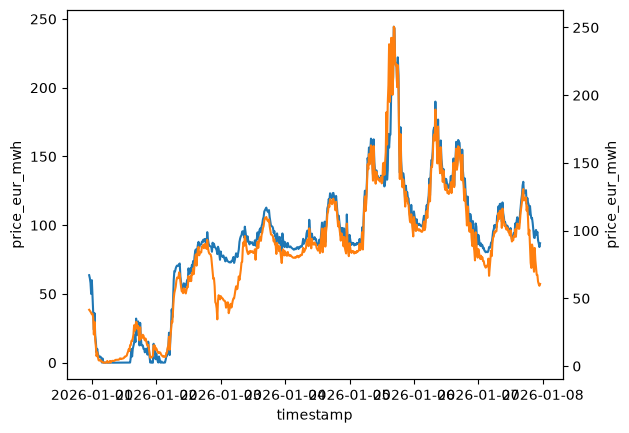

In [150]:
fig, ax1 = plt.subplots()
sns.lineplot(data=prices_df[prices_df.zone=='DE_LU'], x='timestamp', y='price_eur_mwh', ax=ax1, color='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=prices_df[prices_df.zone=='SE_4'], x='timestamp', y='price_eur_mwh', ax=ax2, color='tab:orange')

In [151]:
flows_df.head()

,zone_from,zone_to,timestamp,flow_mw
0,DE_LU,SE_4,2025-12-31 23:00:00+00:00,0.0
1,DE_LU,SE_4,2025-12-31 23:15:00+00:00,0.0
2,DE_LU,SE_4,2025-12-31 23:30:00+00:00,0.0
3,DE_LU,SE_4,2025-12-31 23:45:00+00:00,0.0
4,DE_LU,SE_4,2026-01-01 00:00:00+00:00,0.0


<Axes: xlabel='timestamp', ylabel='flow_mw'>

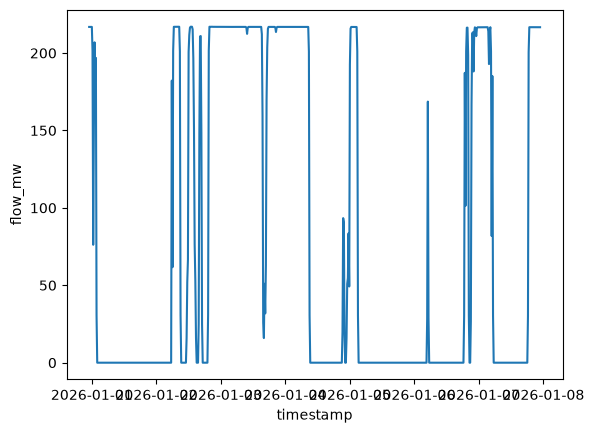

In [152]:
fig, ax3 = plt.subplots()
sns.lineplot(data=flows_df[flows_df["zone_from"]=='SE_4'], x='timestamp', y='flow_mw', ax=ax3, color='tab:blue')

<Axes: xlabel='timestamp', ylabel='flow_mw'>

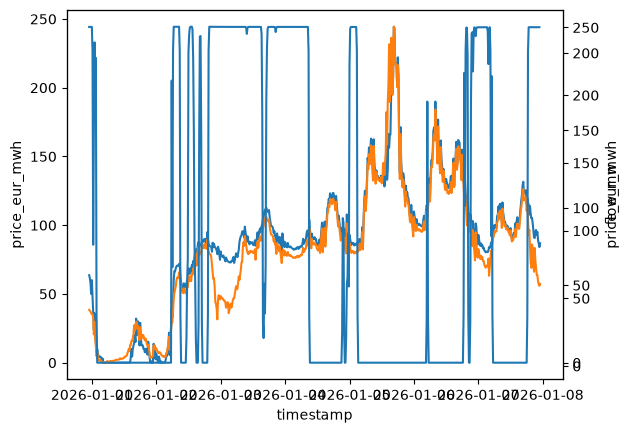

In [153]:
fig, ax1 = plt.subplots()
sns.lineplot(data=prices_df[prices_df.zone=='DE_LU'], x='timestamp', y='price_eur_mwh', ax=ax1, color='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=prices_df[prices_df.zone=='SE_4'], x='timestamp', y='price_eur_mwh', ax=ax2, color='tab:orange')
ax3 = ax1.twinx()
sns.lineplot(data=flows_df[flows_df["zone_from"]=='SE_4'], x='timestamp', y='flow_mw', ax=ax3, color='tab:blue')

Yes, its ugly as can be with all three graphs overlaid, but yes, we see a decoupling with lower prices in sweden when the flow cap is reached. Really cool. We'd need to check transfer over Denmark for a complete analysis, but this is a cool indication.

Lets look at generation shares:

In [154]:
generation_wide_df

production_type                      Biomass  Fossil Brown coal/Lignite  \
zone  timestamp                                                           
DE_LU 2025-12-31 23:00:00+00:00  4210.669292                 4364.73245   
      2025-12-31 23:15:00+00:00  4219.440200                 4021.99555   
      2025-12-31 23:30:00+00:00  4204.712552                 3816.62234   
      2025-12-31 23:45:00+00:00  4183.863608                 3587.41778   
      2026-01-01 00:00:00+00:00  4157.940284                 3125.83925   
...                                      ...                        ...   
SE_4  2026-01-07 21:45:00+00:00          NaN                        NaN   
      2026-01-07 22:00:00+00:00          NaN                        NaN   
      2026-01-07 22:15:00+00:00          NaN                        NaN   
      2026-01-07 22:30:00+00:00          NaN                        NaN   
      2026-01-07 22:45:00+00:00          NaN                        NaN   

production_type                  Fossil Coal-derived gas   Fossil Gas  \
zone  timestamp                                                         
DE_LU 2025-12-31 23:00:00+00:00                562.04667  6662.260660   
      2025-12-31 23:15:00+00:00                621.40334  6381.432660   
      2025-12-31 23:30:00+00:00                623.93333  6215.596999   
      2025-12-31 23:45:00+00:00                596.95999  6134.690650   
      2026-01-01 00:00:00+00:00                583.98333  5853.217000   
...                                                  ...          ...   
SE_4  2026-01-07 21:45:00+00:00                      NaN     0.100000   
      2026-01-07 22:00:00+00:00                      NaN     0.000000   
      2026-01-07 22:15:00+00:00                      NaN     0.000000   
      2026-01-07 22:30:00+00:00                      NaN     0.000000   
      2026-01-07 22:45:00+00:00                      NaN     0.000000   

production_type                  Fossil Hard coal  Fossil Oil  Geothermal  \
zone  timestamp                                                             
DE_LU 2025-12-31 23:00:00+00:00       4729.875683   395.34600    34.79172   
      2025-12-31 23:15:00+00:00       4556.335678   395.32000    34.84380   
      2025-12-31 23:30:00+00:00       4425.860408   395.58000    34.73164   
      2025-12-31 23:45:00+00:00       4410.482520   395.45333    34.76356   
      2026-01-01 00:00:00+00:00       4419.183129   395.58000    34.67276   
...                                           ...         ...         ...   
SE_4  2026-01-07 21:45:00+00:00               NaN         NaN         NaN   
      2026-01-07 22:00:00+00:00               NaN         NaN         NaN   
      2026-01-07 22:15:00+00:00               NaN         NaN         NaN   
      2026-01-07 22:30:00+00:00               NaN         NaN         NaN   
      2026-01-07 22:45:00+00:00               NaN         NaN         NaN   

production_type                  Hydro Pumped Storage  \
zone  timestamp                                         
DE_LU 2025-12-31 23:00:00+00:00              352.8485   
      2025-12-31 23:15:00+00:00              601.6666   
      2025-12-31 23:30:00+00:00              -95.2674   
      2025-12-31 23:45:00+00:00               74.5468   
      2026-01-01 00:00:00+00:00              326.6449   
...                                               ...   
SE_4  2026-01-07 21:45:00+00:00                   NaN   
      2026-01-07 22:00:00+00:00                   NaN   
      2026-01-07 22:15:00+00:00                   NaN   
      2026-01-07 22:30:00+00:00                   NaN   
      2026-01-07 22:45:00+00:00                   NaN   

production_type                  Hydro Run-of-river and poundage  \
zone  timestamp                                                    
DE_LU 2025-12-31 23:00:00+00:00                        978.01191   
      2025-12-31 23:15:00+00:00                        960.89287   
      2025-12-31 23:30:00+00:00                        981

ok we create a new table with renewables share - we define only solar and wind at this point, and explicitly exclude water. Might want to reconsider that later.

In [166]:
genx=generation_wide_df.reset_index().copy()
genx['renewables_generation']=genx[['Wind Onshore','Wind Offshore','Solar']].sum(axis=1)
production_cols = generation_wide_df.columns.tolist()
genx['total_generation_mw']=genx[production_cols].sum(axis=1)
genx['renewables_share']=genx['renewables_generation']/genx['total_generation_mw']
renewables_share=genx[["zone", "timestamp", "renewables_share"]].copy()


Lets check the renewable share over time in a plot just for fun:

<Axes: xlabel='timestamp', ylabel='renewables_share'>

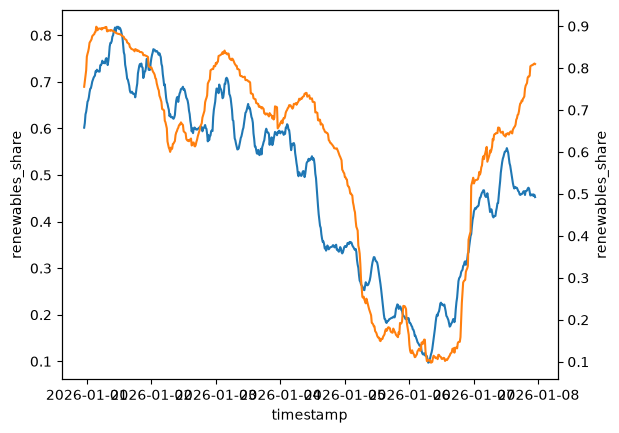

In [167]:
fig, ax1 = plt.subplots()
sns.lineplot(data=renewables_share[renewables_share.zone=='DE_LU'], x='timestamp', y='renewables_share', ax=ax1, color='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=renewables_share[renewables_share.zone=='SE_4'], x='timestamp', y='renewables_share', ax=ax2, color='tab:orange')

Ok, price and share separately for both countries?

<Axes: xlabel='timestamp', ylabel='price_eur_mwh'>

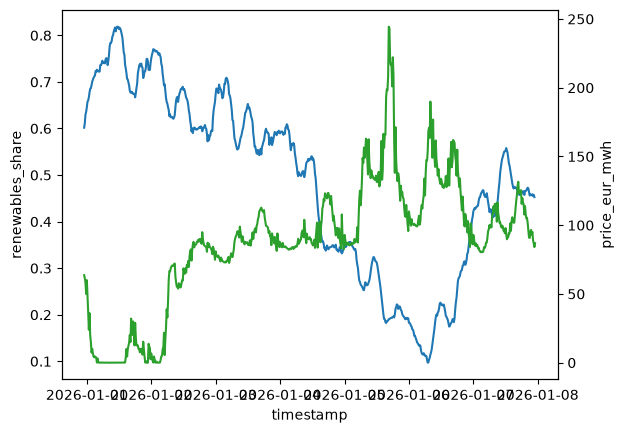

In [169]:
fig, ax1 = plt.subplots()
sns.lineplot(data=renewables_share[renewables_share.zone=='DE_LU'], x='timestamp', y='renewables_share', ax=ax1, color='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=prices_df[prices_df.zone=='DE_LU'], x='timestamp', y='price_eur_mwh', ax=ax2, color='tab:green')

<Axes: xlabel='timestamp', ylabel='price_eur_mwh'>

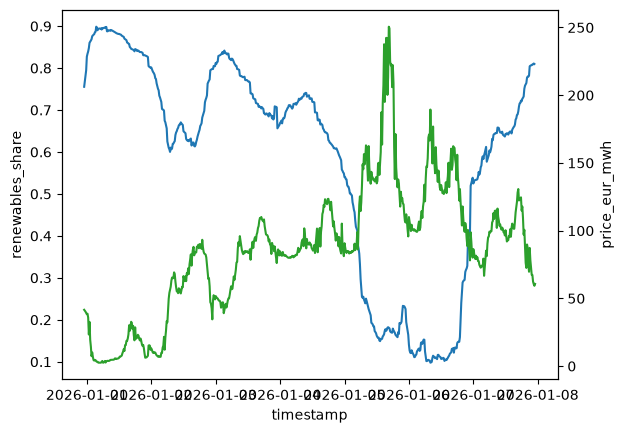

In [170]:
fig, ax1 = plt.subplots()
sns.lineplot(data=renewables_share[renewables_share.zone=='SE_4'], x='timestamp', y='renewables_share', ax=ax1, color='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=prices_df[prices_df.zone=='SE_4'], x='timestamp', y='price_eur_mwh', ax=ax2, color='tab:green')

In [172]:
renewables_share.info()

<class 'pandas.DataFrame'>
RangeIndex: 1344 entries, 0 to 1343
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   zone              1344 non-null   str                
 1   timestamp         1344 non-null   datetime64[us, UTC]
 2   renewables_share  1344 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), str(1)
memory usage: 31.6 KB


In [173]:
prices_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   zone           1346 non-null   str                
 1   timestamp      1346 non-null   datetime64[us, UTC]
 2   price_eur_mwh  1346 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), str(1)
memory usage: 31.7 KB


We build yet another df for further analysis. We now want to get at rolling volatility.

In [174]:
analysis_df=prices_df.merge(renewables_share, on=['zone', 'timestamp'], how='left').dropna(subset=['renewables_share'])

In [179]:
analysis_df

,zone,timestamp,price_eur_mwh,renewables_share
0,DE_LU,2025-12-31 23:00:00+00:00,63.64,0.601711
1,DE_LU,2025-12-31 23:15:00+00:00,61.48,0.611846
2,DE_LU,2025-12-31 23:30:00+00:00,58.00,0.630356
3,DE_LU,2025-12-31 23:45:00+00:00,49.99,0.636005
4,DE_LU,2026-01-01 00:00:00+00:00,60.01,0.645945
...,...,...,...,...
1340,SE_4,2026-01-07 21:45:00+00:00,67.38,0.806913
1341,SE_4,2026-01-07 22:00:00+00:00,67.26,0.808671
1342,SE_4,2026-01-07 22:15:00+00:00,62.37,0.808723
1343,SE_4,2026-01-07 22:30:00+00:00,60.56,0.810971


Ok now lets pretend to be statisticians.

We do a rolling 24 hour window measuring the standard deviation as a measure of volatility (96 * 15 mins, the first 24 hours gets dropped due to no data existing for a rolling window).

In [186]:
analysis_df.loc[analysis_df['zone'] == 'SE_4']['price_eur_mwh'].rolling(96).std().dropna()

768     11.290820
769     10.915376
770     10.539882
771     10.161864
772      9.787102
          ...    
1340    15.644697
1341    15.890512
1342    16.222534
1343    16.562364
1344    16.863228
Name: price_eur_mwh, Length: 577, dtype: float64

In [187]:
analysis_df.loc[analysis_df['zone'] == 'DE_LU']['price_eur_mwh'].rolling(96).std().dropna()

95     15.303947
96     14.266775
97     13.214066
98     12.199826
99     11.426671
         ...    
667    12.638614
668    12.641902
669    12.674994
670    12.704773
671    12.706162
Name: price_eur_mwh, Length: 577, dtype: float64

Ok, as an alternative, here's a monster of a code line. Its all to keep the time stamp while grouping to make the rolling volatility separate the two zones, and then basically ungrouping again. Ugly hack, but it works.

In [190]:
rolling_df = analysis_df.set_index('timestamp').groupby('zone')['price_eur_mwh'].rolling(96).std().dropna().reset_index().rename(columns={'price_eur_mwh': 'rolling_volatility'})

In [193]:
rolling_df

,zone,timestamp,rolling_volatility
0,DE_LU,2026-01-01 22:45:00+00:00,15.303947
1,DE_LU,2026-01-01 23:00:00+00:00,14.266775
2,DE_LU,2026-01-01 23:15:00+00:00,13.214066
3,DE_LU,2026-01-01 23:30:00+00:00,12.199826
4,DE_LU,2026-01-01 23:45:00+00:00,11.426671
...,...,...,...
1149,SE_4,2026-01-07 21:45:00+00:00,15.644697
1150,SE_4,2026-01-07 22:00:00+00:00,15.890512
1151,SE_4,2026-01-07 22:15:00+00:00,16.222534
1152,SE_4,2026-01-07 22:30:00+00:00,16.562364


Ok, lets get to the analysis of comparing the volatility with the renewables share finally!

In [194]:
scatter_df = rolling_df.merge(renewables_share, on=['zone', 'timestamp'], how='inner')

<Axes: xlabel='renewables_share', ylabel='rolling_volatility'>

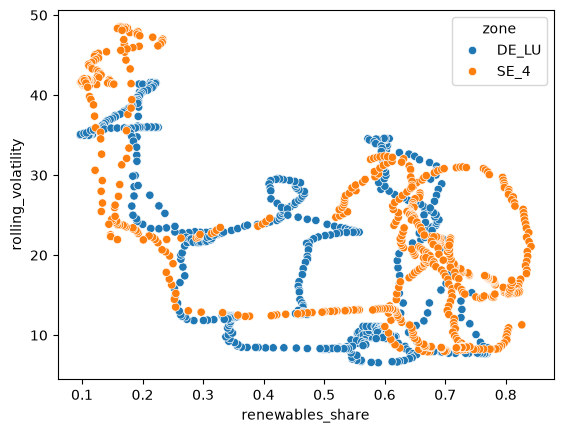

In [195]:
sns.scatterplot(data=scatter_df, x='renewables_share', y='rolling_volatility', hue='zone')

THat.... looks odd. Like paths. Wow.

<Axes: xlabel='timestamp', ylabel='rolling_volatility'>

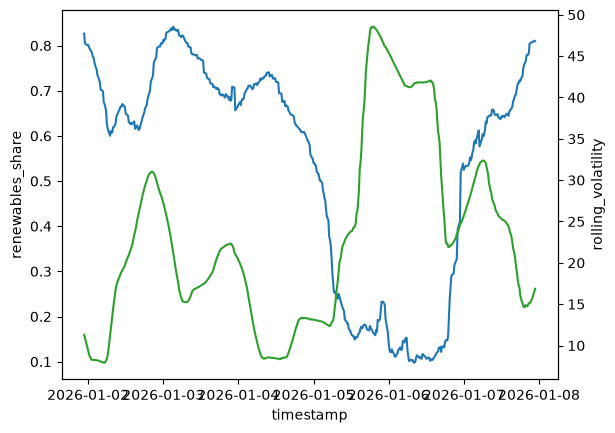

In [196]:
fig, ax1 = plt.subplots()
sns.lineplot(data=scatter_df[scatter_df.zone=='SE_4'], x='timestamp', y='renewables_share', ax=ax1, color='tab:blue')
ax2 = ax1.twinx()
sns.lineplot(data=scatter_df[scatter_df.zone=='SE_4'], x='timestamp', y='rolling_volatility', ax=ax2, color='tab:green')

Now THAT looks inverse proportional. Can we test that?

MORE STATS! CORRELATION TEST:

In [197]:
scatter_df.groupby('zone')[['renewables_share', 'rolling_volatility']].corr(method='spearman')

renewables_share  rolling_volatility
zone                                                          
DE_LU renewables_share            1.000000           -0.497726
      rolling_volatility         -0.497726            1.000000
SE_4  renewables_share            1.000000           -0.572946
      rolling_volatility         -0.572946            1.000000

That's uh odd, the correlation is negative. Higher proportion of renewables seem to imply LOWER volatility. The rolling variable might be the a problem. Lets try Newey-West (HAC).

In [200]:
import statsmodels.formula.api as smf

model = smf.ols('rolling_volatility ~ renewables_share * C(zone)', data=scatter_df)

naive_result = model.fit()
hac_result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 96})

In [204]:
naive_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     rolling_volatility   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     249.1
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          1.54e-124
Time:                        22:22:08   Log-Likelihood:                -4117.3
No. Observations:                1154   AIC:                             8243.
Df Residuals:                    1150   BIC:                             8263.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           34.4879      0.956     36.084      0.000      32.613      36.363
C(zone)[T.SE_4]                      5.6562      1.284      4.405      0.000       3.137       8.175
renewables_share                   -31.1547      1.986    -15.685      0.000     -35.052     -27.258
renewables_share:C(zone)[T.SE_4]    -0.5615      2.462     -0.228      0.820      -5.391       4.268
==============================================================================
Omnibus:                      228.515   Durbin-Watson:                   0.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.911
Skew:                           0.139   Prob(JB):                     1.45e-11
Kurtosis:                       2.020   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<!-- Durbin-Watson tells us that this result is terrible though. -->

In [205]:
hac_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     rolling_volatility   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.392
Method:                 Least Squares   F-statistic:                     9.082
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           6.06e-06
Time:                        22:22:14   Log-Likelihood:                -4117.3
No. Observations:                1154   AIC:                             8243.
Df Residuals:                    1150   BIC:                             8263.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           34.4879      6.112      5.642      0.000      22.508      46.468
C(zone)[T.SE_4]                      5.6562      7.473      0.757      0.449      -8.990      20.302
renewables_share                   -31.1547     12.624     -2.468      0.014     -55.898      -6.411
renewables_share:C(zone)[T.SE_4]    -0.5615     14.422     -0.039      0.969     -28.829      27.706
==============================================================================
Omnibus:                      228.515   Durbin-Watson:                   0.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               49.911
Skew:                           0.139   Prob(JB):                     1.45e-11
Kurtosis:                       2.020   Cond. No.                         17.0
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 96 lags and without small sample correction
"""

Ok so, this tells us that the two countries does not behave differently in this regard (see the C(zone variants)), but the "renewable share" line with P 0.014 tells us that yes, there probably is a negative correlation. Cool. Lets see how that changes in the final analysis.